In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error

In [2]:
# --- Load data ---
data = pd.read_csv('/content/drive/MyDrive/TimeSeriesForecasting/Day5/AirPassengers.csv')
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)
data.rename(columns={'#Passengers': 'Passengers'}, inplace=True)

In [3]:
data

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [4]:
# --- Transformations ---
data["Passenger_Log"] = np.log(data["Passengers"]) # Remove the variance from the data
data["Passenger_Diff_Log"] = data["Passenger_Log"].diff() # Removes the trend from the data
data['Passengers_log_diff_seasonal'] = data['Passenger_Diff_Log'].diff(12) #Removes the seasonality from the data
data.dropna(inplace=True)

In [5]:
# --- Train-Test Split ---
test_horizon = 24
train = data["Passengers_log_diff_seasonal"].iloc[:-test_horizon]
test  = data["Passengers_log_diff_seasonal"].iloc[-test_horizon:]

# --- Build AR Model ---
# ARmodel = ARIMA(train, order=(1,0,0))
# arma_res = ARmodel.fit()

# # Forecast
# fc_log_diff_seasonal = arma_res.forecast(steps=test_horizon)

# # --- Build ARMA Model ---

arma_model = ARIMA(train, order=(1,0,1))
arma_res = arma_model.fit()

# Forecast
fc_log_diff_seasonal = arma_res.forecast(steps=test_horizon)


# #MA model
# model = ARIMA(train, order=(0, 0, 1))
# res = model.fit()
# fc_log_diff_seasonal = res.forecast(steps=test_horizon)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [6]:

# --- Reverse transformations for forecast ---
# Step 1: Reverse seasonal differencing
fc_log_diff = fc_log_diff_seasonal + data["Passenger_Diff_Log"].iloc[-test_horizon-12:-12].values

# Step 2: Reverse regular differencing
fc_log = fc_log_diff + data["Passenger_Log"].iloc[-test_horizon-1:-1].values

# Step 3: Reverse log
fc = np.exp(fc_log)

In [7]:
# --- Original test values ---
test_original = data["Passengers"].iloc[-test_horizon:]

In [8]:

# --- Metrics ---
mape = mean_absolute_percentage_error(test_original, fc)
mae  = mean_absolute_error(test_original, fc)
print(f"MAPE: {mape*100:.2f}%")
print(f"MAE : {mae:.2f}")

MAPE: 3.36%
MAE : 14.93


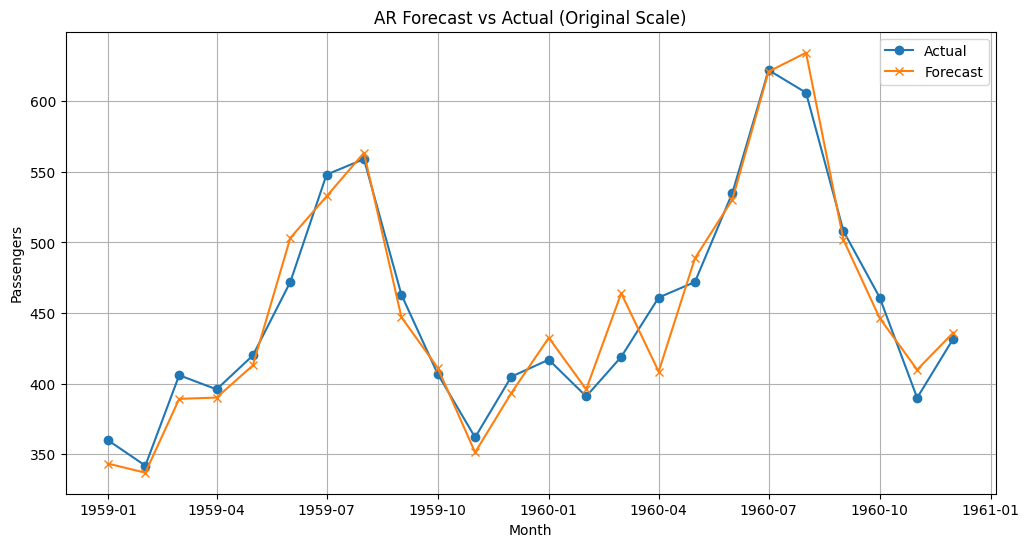

In [9]:


# --- Plot ---
plt.figure(figsize=(12,6))
plt.plot(test_original.index, test_original, label="Actual", marker='o')
plt.plot(test_original.index, fc, label="Forecast", marker='x')
plt.title("AR Forecast vs Actual (Original Scale)")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True)
plt.show()


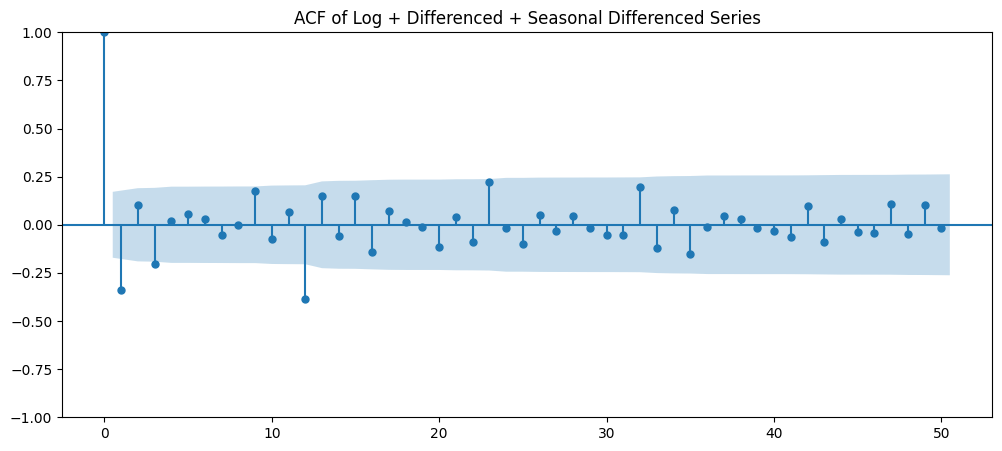

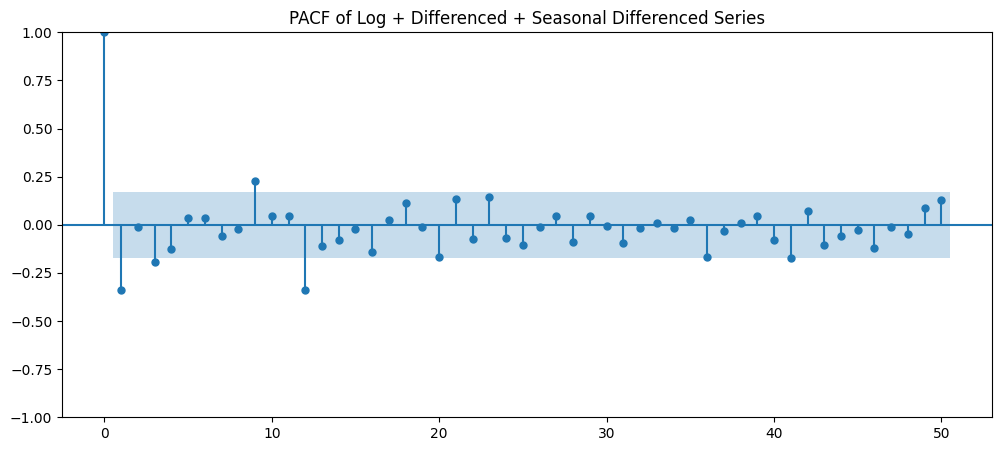

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# --- Transformed series ---
ts = data['Passengers_log_diff_seasonal']

# --- Plot ACF ---
plt.figure(figsize=(12,5))
plot_acf(ts, lags=50, ax=plt.gca())
plt.title("ACF of Log + Differenced + Seasonal Differenced Series")
plt.show()

# --- Plot PACF ---
plt.figure(figsize=(12,5))
plot_pacf(ts, lags=50, ax=plt.gca(), method='ywm')
plt.title("PACF of Log + Differenced + Seasonal Differenced Series")
plt.show()


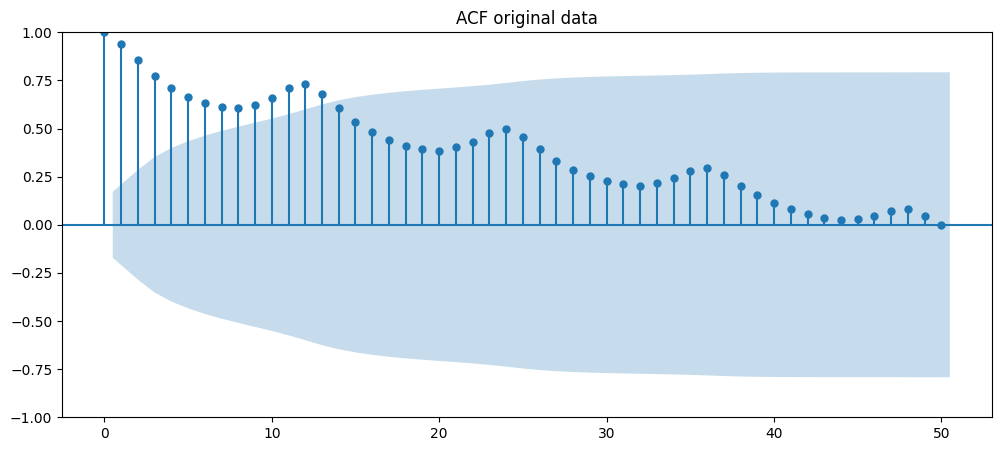

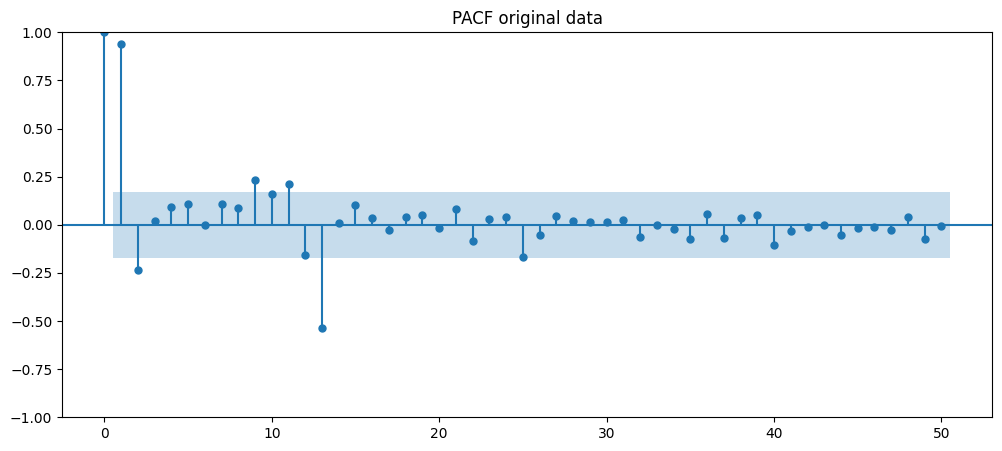

In [11]:
# --- Transformed series ---
ts = data['Passengers']

# --- Plot ACF ---
plt.figure(figsize=(12,5))
plot_acf(ts, lags=50, ax=plt.gca())
plt.title("ACF original data")
plt.show()

# --- Plot PACF ---
plt.figure(figsize=(12,5))
plot_pacf(ts, lags=50, ax=plt.gca(), method='ywm')
plt.title("PACF original data")
plt.show()


In [12]:
from statsmodels.tsa.arima.model import ARIMA
arma_model = ARIMA(train, order=(1,0,1))
arma_res = arma_model.fit()

# Forecast
fc_arma = arma_res.forecast(steps=test_horizon)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
